In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/steel_mechanical_properties_435.csv")

# Basic inspection
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (435, 21)

Column Names:
['Sample_ID', 'Al', 'AlS', 'C', 'Cr', 'Cu', 'Mn', 'Mo', 'N', 'Nb', 'Ni', 'P', 'S', 'Si', 'Ti', 'V', 'FRT', 'CTT', 'YS', 'UTS', 'EL']

First 5 Rows:


,Sample_ID,Al,AlS,C,Cr,Cu,Mn,Mo,N,Nb,...,P,S,Si,Ti,V,FRT,CTT,YS,UTS,EL
0,1,0.040,0.039,0.050,0.029,0.006,0.29,0.001,36,0.001,...,0.016,0.018,0.008,0.001,0.001,864.92,650,263,357,40
1,2,0.032,0.030,0.035,0.024,0.006,0.19,0.002,58,0.002,...,0.010,0.010,0.014,0.002,0.002,867.39,570,242,363,38
2,3,0.045,0.044,0.035,0.030,0.007,0.24,0.001,35,0.001,...,0.013,0.015,0.010,0.001,0.001,876.93,570,318,367,37
3,4,0.042,0.041,0.050,0.029,0.006,0.30,0.001,42,0.001,...,0.016,0.013,0.007,0.001,0.001,891.54,650,285,367,39
4,5,0.042,0.040,0.045,0.031,0.006,0.21,0.001,38,0.001,...,0.018,0.010,0.011,0.000,0.001,870.86,570,283,355,43


In [2]:
# Check data types and missing values

print("Data Types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame(name="Missing Count"))

Data Types:


,Data Type
Sample_ID,int64
Al,float64
AlS,float64
C,float64
Cr,float64
Cu,float64
Mn,float64
Mo,float64
N,int64
Nb,float64



Missing Values:


,Missing Count
Sample_ID,0
Al,0
AlS,0
C,0
Cr,0
Cu,0
Mn,0
Mo,0
N,0
Nb,0


In [3]:
# Check for duplicate observations

duplicate_rows = df.duplicated().sum()
duplicate_ids = df["Sample_ID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate Sample_IDs:", duplicate_ids)

Duplicate rows: 0
Duplicate Sample_IDs: 0


In [4]:
# Descriptive statistics for all numerical variables

pd.set_option("display.max_columns", None)

summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Sample_ID,435.0,218.000000,125.717938,1.000,109.500,218.000,326.500,435.000
Al,435.0,0.042614,0.008708,0.021,0.037,0.042,0.048,0.065
AlS,435.0,0.040699,0.008664,0.020,0.035,0.040,0.046,0.063
C,435.0,0.042437,0.008664,0.020,0.040,0.045,0.050,0.060
Cr,435.0,0.025621,0.004683,0.014,0.022,0.025,0.029,0.039
Cu,435.0,0.006037,0.001197,0.005,0.005,0.006,0.006,0.012
Mn,435.0,0.260414,0.045323,0.170,0.230,0.270,0.300,0.380
Mo,435.0,0.001460,0.000526,0.001,0.001,0.001,0.002,0.003
N,435.0,36.411494,5.508549,26.000,33.000,36.000,38.000,58.000
Nb,435.0,0.001071,0.000457,0.000,0.001,0.001,0.001,0.004


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

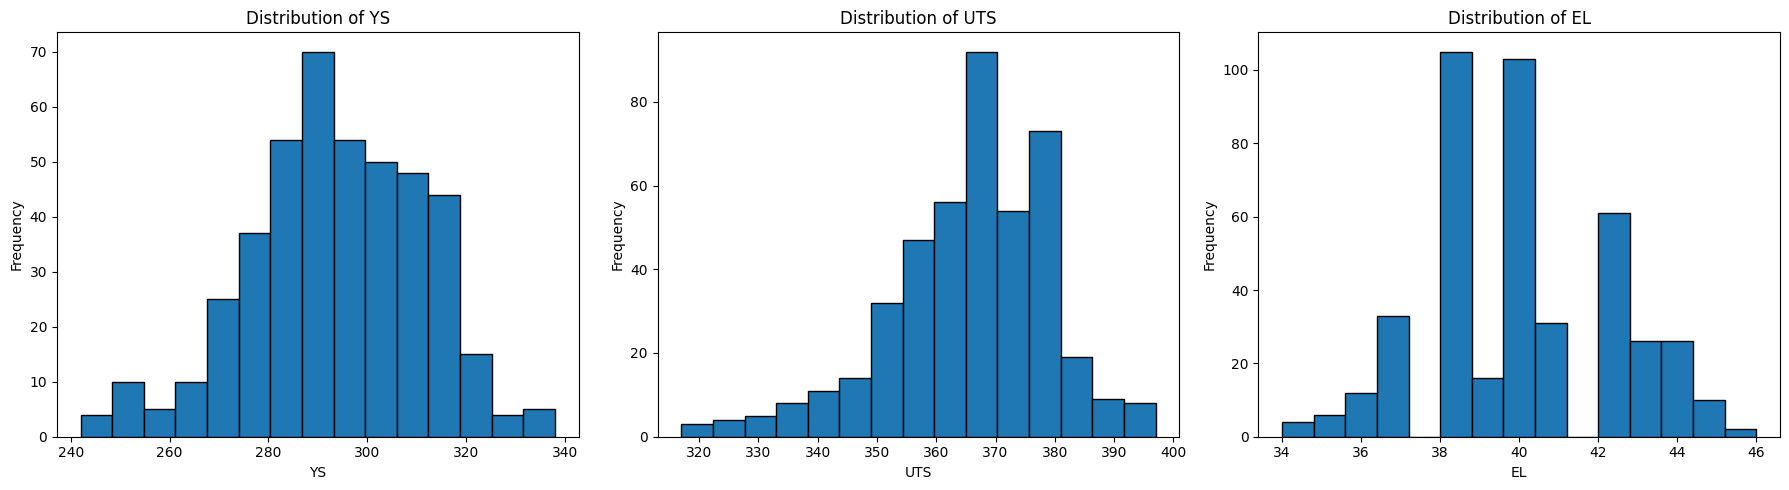

In [7]:
# Target variable distributions

targets = ["YS", "UTS", "EL"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):
    ax.hist(df[target], bins=15, edgecolor="black")
    ax.set_title(f"Distribution of {target}")
    ax.set_xlabel(target)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

targets = ["YS", "UTS", "EL"]

for target in targets:
    statistic, p_value = stats.shapiro(df[target])

    print(f"{target}:")
    print(f"  Shapiro-Wilk statistic = {statistic:.4f}")
    print(f"  p-value = {p_value:.6f}")
    print()

YS:
  Shapiro-Wilk statistic = 0.9914
  p-value = 0.012635

UTS:
  Shapiro-Wilk statistic = 0.9622
  p-value = 0.000000

EL:
  Shapiro-Wilk statistic = 0.9630
  p-value = 0.000000



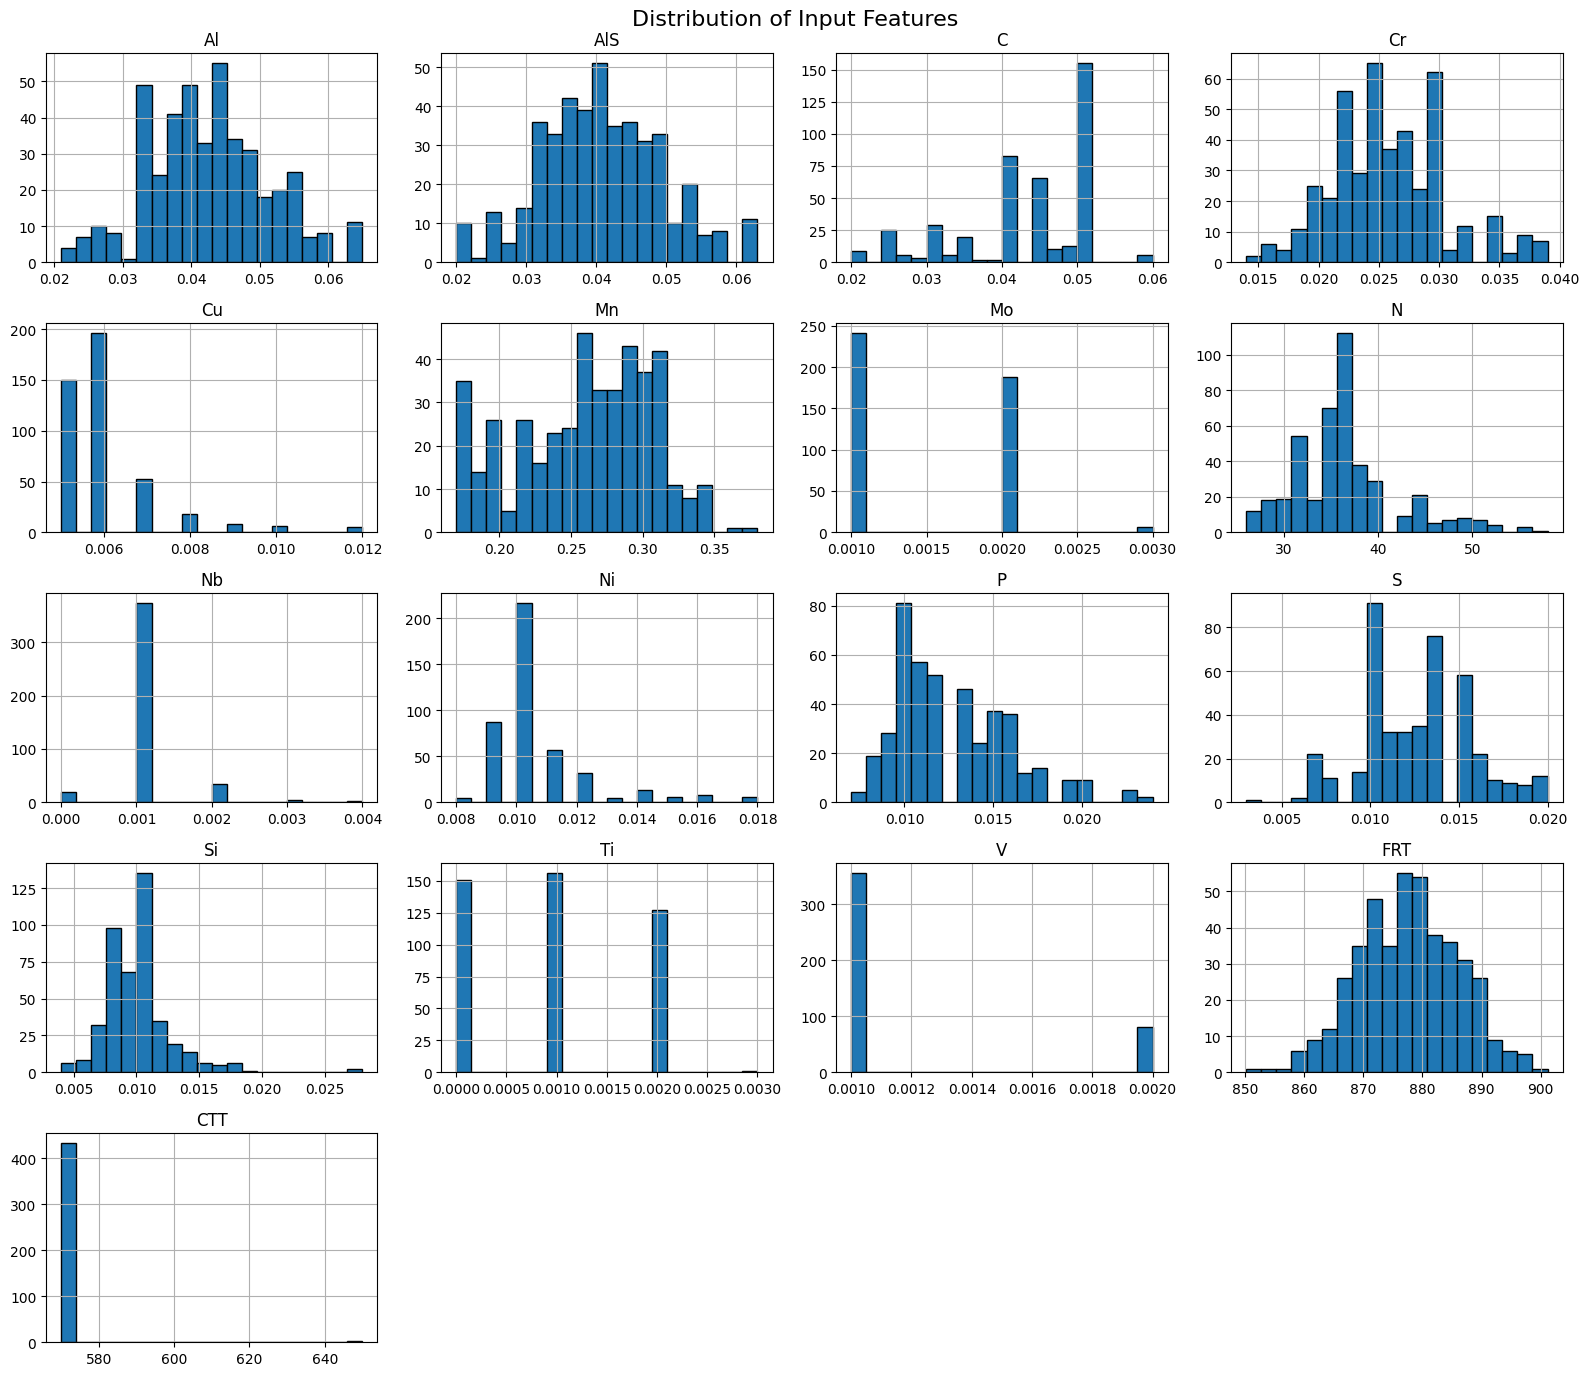

In [9]:
# Distribution of all input features

feature_cols = [
    "Al", "AlS", "C", "Cr", "Cu", "Mn", "Mo",
    "N", "Nb", "Ni", "P", "S", "Si", "Ti",
    "V", "FRT", "CTT"
]

df[feature_cols].hist(
    bins=20,
    figsize=(16, 14),
    edgecolor="black"
)

plt.suptitle("Distribution of Input Features", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# Check number of unique values in each input feature

unique_counts = df[feature_cols].nunique().sort_values()

display(
    unique_counts.to_frame(name="Unique Values")
)

,Unique Values
V,2
CTT,2
Mo,3
Ti,4
Nb,5
Cu,7
Ni,10
P,16
S,16
Si,18


In [11]:
# Inspect low-cardinality features

low_cardinality_features = ["V", "CTT", "Mo", "Ti", "Nb"]

for feature in low_cardinality_features:
    print(f"\n{feature}")
    print("-" * 30)
    display(
        df[feature]
        .value_counts()
        .sort_index()
        .to_frame(name="Count")
    )


V
------------------------------


,Count
V,
0.001,355
0.002,80



CTT
------------------------------


,Count
CTT,
570,432
650,3



Mo
------------------------------


,Count
Mo,
0.001,241
0.002,188
0.003,6



Ti
------------------------------


,Count
Ti,
0.000,151
0.001,156
0.002,127
0.003,1



Nb
------------------------------


,Count
Nb,
0.000,20
0.001,373
0.002,35
0.003,5
0.004,2


In [12]:
# Inspect the rare CTT = 650 observations

ctt_650 = df[df["CTT"] == 650]

display(ctt_650)

,Sample_ID,Al,AlS,C,Cr,Cu,Mn,Mo,N,Nb,Ni,P,S,Si,Ti,V,FRT,CTT,YS,UTS,EL
0,1,0.040,0.039,0.05,0.029,0.006,0.29,0.001,36,0.001,0.010,0.016,0.018,0.008,0.001,0.001,864.92,650,263,357,40
3,4,0.042,0.041,0.05,0.029,0.006,0.30,0.001,42,0.001,0.011,0.016,0.013,0.007,0.001,0.001,891.54,650,285,367,39
25,26,0.037,0.035,0.05,0.030,0.005,0.30,0.002,34,0.001,0.011,0.014,0.012,0.006,0.000,0.002,870.33,650,262,333,45


In [13]:
# Compare mechanical properties across CTT levels

ctt_summary = df.groupby("CTT")[["YS", "UTS", "EL"]].agg(
    ["count", "mean", "std", "min", "max"]
)

ctt_summary

YS                                    UTS                              \
    count        mean        std  min  max count        mean        std  min   
CTT                                                                            
570   432  293.905093  17.636778  242  338   432  365.474537  13.469198  317   
650     3  270.000000  13.000000  262  285     3  352.333333  17.473790  333   

            EL                               
     max count       mean       std min max  
CTT                                          
570  397   432  39.921296  2.378034  34  46  
650  367     3  41.333333  3.214550  39  45

In [14]:
# IQR-based potential outlier detection

analysis_cols = feature_cols + ["YS", "UTS", "EL"]

outlier_summary = []

for col in analysis_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "Outlier Count",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
14,V,0.001,0.001,0.000,0.0010,0.0010,80
8,Nb,0.001,0.001,0.000,0.0010,0.0010,62
9,Ni,0.010,0.011,0.001,0.0085,0.0125,43
4,Cu,0.005,0.006,0.001,0.0035,0.0075,37
7,N,33.000,38.000,5.000,25.5000,45.5000,35
12,Si,0.008,0.011,0.003,0.0035,0.0155,14
18,UTS,358.500,375.500,17.000,333.0000,401.0000,12
2,C,0.040,0.050,0.010,0.0250,0.0650,12
10,P,0.010,0.015,0.005,0.0025,0.0225,7
0,Al,0.037,0.048,0.011,0.0205,0.0645,5


In [15]:
# Check whether identical feature combinations occur
# even when the complete rows are different

feature_duplicates = df.duplicated(
    subset=feature_cols,
    keep=False
)

print("Rows belonging to repeated feature combinations:",
      feature_duplicates.sum())

print("Number of unique feature combinations:",
      df[feature_cols].drop_duplicates().shape[0])

# Show some repeated combinations
repeated_features = (
    df.loc[feature_duplicates, feature_cols]
      .value_counts()
      .reset_index(name="Count")
)

display(repeated_features.head(10))

Rows belonging to repeated feature combinations: 0
Number of unique feature combinations: 435


,Al,AlS,C,Cr,Cu,Mn,Mo,N,Nb,Ni,P,S,Si,Ti,V,FRT,CTT,Count


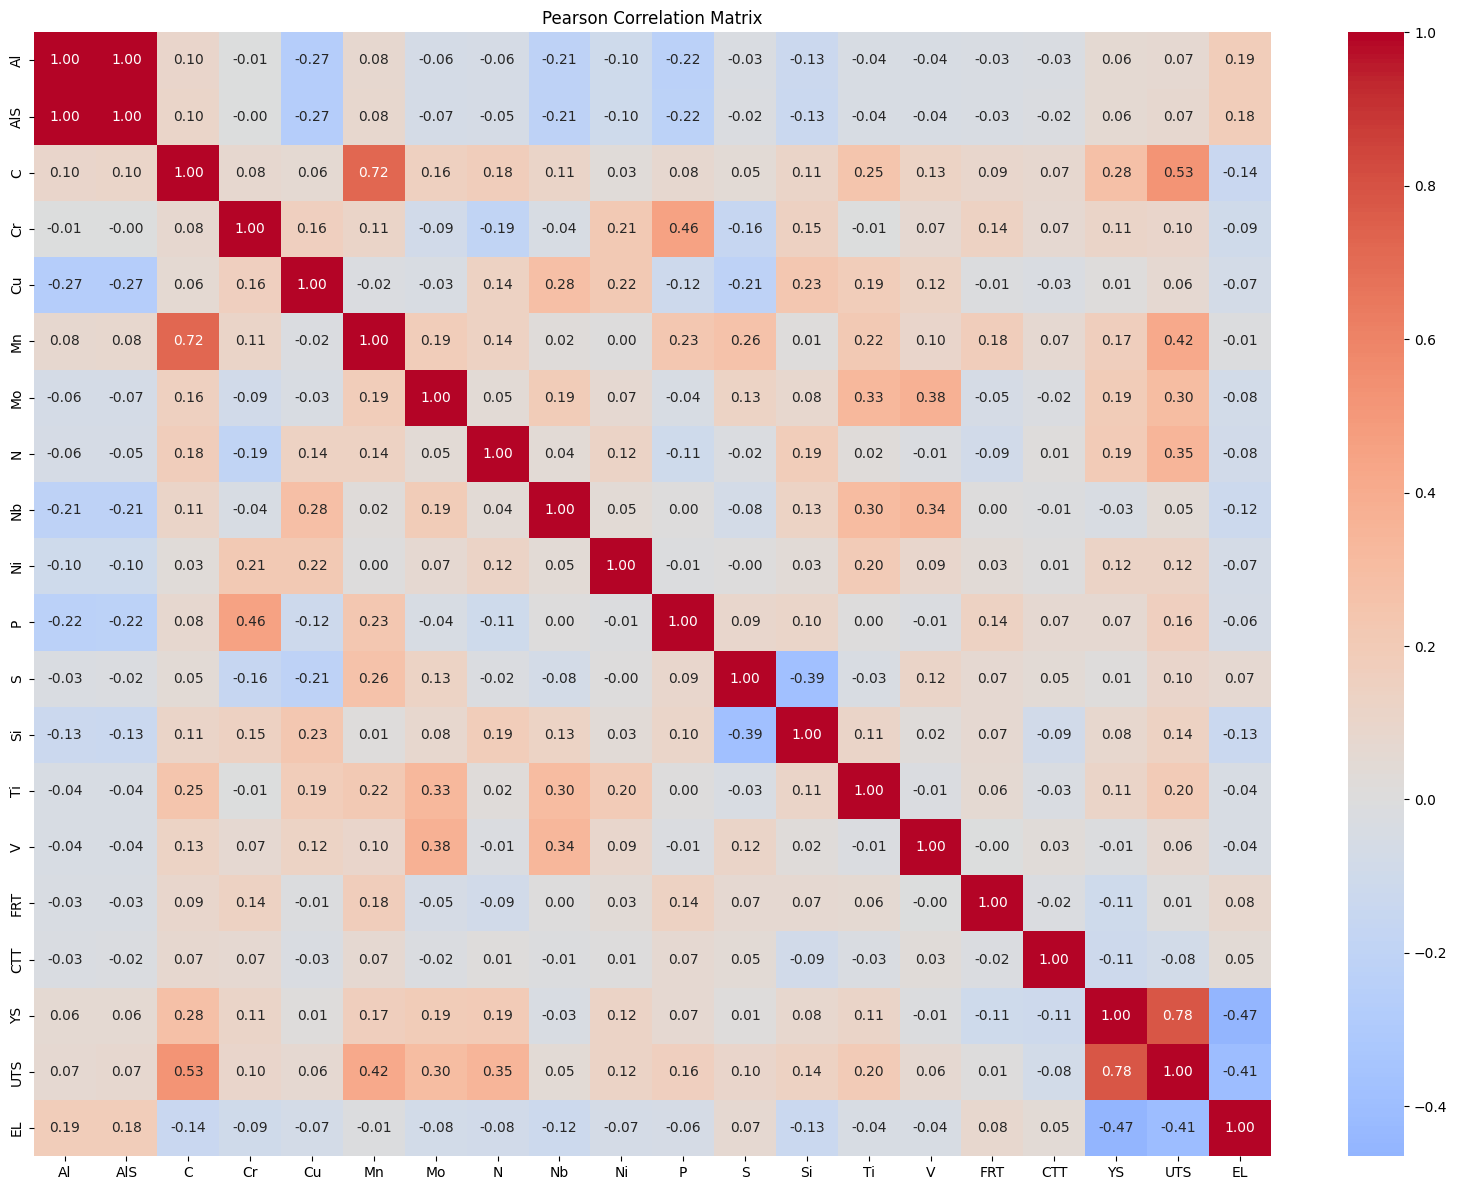

In [16]:
# Correlation matrix for all features and targets

correlation_data = df[feature_cols + ["YS", "UTS", "EL"]]

corr_matrix = correlation_data.corr(method="pearson")

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
from scipy.stats import pearsonr

targets = ["YS", "UTS", "EL"]

correlation_results = []

for feature in feature_cols:
    for target in targets:
        r, p = pearsonr(df[feature], df[target])

        correlation_results.append({
            "Feature": feature,
            "Target": target,
            "Pearson_r": r,
            "p_value": p,
            "Significant_0.05": p < 0.05
        })

pearson_results = pd.DataFrame(correlation_results)

display(
    pearson_results.sort_values(
        ["Target", "p_value"]
    )
)

,Feature,Target,Pearson_r,p_value,Significant_0.05
2,Al,EL,0.186380,9.214215e-05,True
5,AlS,EL,0.182148,1.334147e-04,True
8,C,EL,-0.139286,3.603998e-03,True
38,Si,EL,-0.133556,5.270358e-03,True
26,Nb,EL,-0.120223,1.209565e-02,True
11,Cr,EL,-0.094868,4.799633e-02,True
23,N,EL,-0.083677,8.128707e-02,False
20,Mo,EL,-0.079445,9.796516e-02,False
47,FRT,EL,0.078777,1.008282e-01,False
14,Cu,EL,-0.074267,1.219504e-01,False


In [18]:
from scipy.stats import spearmanr

spearman_results = []

for feature in feature_cols:
    for target in targets:
        rho, p_value = spearmanr(df[feature], df[target])

        spearman_results.append({
            "Feature": feature,
            "Target": target,
            "Spearman_rho": rho,
            "p_value": p_value,
            "Significant_0.05": p_value < 0.05
        })

spearman_results = pd.DataFrame(spearman_results)

display(
    spearman_results.sort_values(
        ["Target", "p_value"]
    )
)

,Feature,Target,Spearman_rho,p_value,Significant_0.05
2,Al,EL,0.195919,3.881976e-05,True
5,AlS,EL,0.190962,6.115279e-05,True
23,N,EL,-0.128687,7.200198e-03,True
26,Nb,EL,-0.125235,8.929015e-03,True
29,Ni,EL,-0.117884,1.388724e-02,True
8,C,EL,-0.116020,1.547755e-02,True
38,Si,EL,-0.108825,2.321074e-02,True
47,FRT,EL,0.086571,7.126515e-02,False
11,Cr,EL,-0.083119,8.334616e-02,False
14,Cu,EL,-0.077304,1.073822e-01,False


In [19]:
# Display complete Spearman results separately for each target

for target in targets:
    print("=" * 70)
    print(f"Spearman correlation with {target}")
    print("=" * 70)

    target_results = (
        spearman_results[spearman_results["Target"] == target]
        .copy()
    )

    target_results["Abs_Rho"] = target_results["Spearman_rho"].abs()

    target_results = target_results.sort_values(
        "Abs_Rho",
        ascending=False
    )

    display(
        target_results[
            ["Feature", "Spearman_rho", "p_value", "Significant_0.05"]
        ].reset_index(drop=True)
    )

Spearman correlation with YS


,Feature,Spearman_rho,p_value,Significant_0.05
0,N,0.229308,0.000001,True
1,Mo,0.159598,0.000836,True
2,C,0.158902,0.000882,True
3,Ti,0.119023,0.012987,True
4,Cr,0.109065,0.022907,True
5,CTT,-0.105660,0.027557,True
6,Ni,0.105309,0.028078,True
7,Mn,0.094851,0.048036,True
8,FRT,-0.073902,0.123799,False
9,Si,0.052425,0.275266,False


Spearman correlation with UTS


,Feature,Spearman_rho,p_value,Significant_0.05
0,C,0.391763,2.083209e-17,True
1,Mn,0.344856,1.361112e-13,True
2,N,0.329565,1.765967e-12,True
3,Mo,0.254942,6.995985e-08,True
4,Ti,0.182557,1.287773e-04,True
5,S,0.126990,8.008784e-03,True
6,P,0.112069,1.938632e-02,True
7,Cr,0.100915,3.537172e-02,True
8,Si,0.100874,3.544850e-02,True
9,Ni,0.077469,1.066324e-01,False


Spearman correlation with EL


,Feature,Spearman_rho,p_value,Significant_0.05
0,Al,0.195919,0.000039,True
1,AlS,0.190962,0.000061,True
2,N,-0.128687,0.007200,True
3,Nb,-0.125235,0.008929,True
4,Ni,-0.117884,0.013887,True
5,C,-0.116020,0.015478,True
6,Si,-0.108825,0.023211,True
7,FRT,0.086571,0.071265,False
8,Cr,-0.083119,0.083346,False
9,Cu,-0.077304,0.107382,False


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[feature_cols].copy()

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

display(vif_df)

,Feature,VIF
0,Al,1000.151560
1,AlS,999.906205
5,Mn,2.668289
2,C,2.326316
3,Cr,1.681869
10,P,1.663816
14,V,1.494337
6,Mo,1.487284
13,Ti,1.482135
11,S,1.470881


Correlation between Al and AlS:
0.9994349919669949

Al - AlS difference statistics:


,0
count,435.000000
mean,0.001915
std,0.000295
min,0.000000
25%,0.002000
50%,0.002000
75%,0.002000
max,0.002000


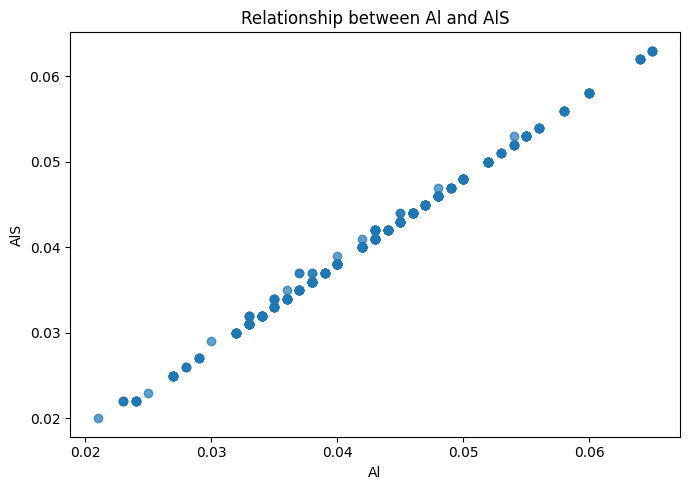

In [21]:
# Examine the Al and AlS relationship

print("Correlation between Al and AlS:")
print(df["Al"].corr(df["AlS"]))

print("\nAl - AlS difference statistics:")
display((df["Al"] - df["AlS"]).describe())

# Scatter plot
plt.figure(figsize=(7, 5))

plt.scatter(df["Al"], df["AlS"], alpha=0.7)

plt.xlabel("Al")
plt.ylabel("AlS")
plt.title("Relationship between Al and AlS")

plt.tight_layout()
plt.show()

In [22]:
# Examine the Al-AlS relationship in detail

al_difference = df["Al"] - df["AlS"]

print("Unique Al - AlS differences:")
print(sorted(al_difference.unique()))

print("\nFrequency of each difference:")
display(
    al_difference.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

Unique Al - AlS differences:
[np.float64(0.0), np.float64(0.000999999999999994), np.float64(0.0009999999999999974), np.float64(0.0010000000000000009), np.float64(0.001999999999999995), np.float64(0.0019999999999999983), np.float64(0.0020000000000000018)]

Frequency of each difference:


,Count
0.000,2
0.001,11
0.001,1
0.001,21
0.002,73
0.002,10
0.002,317


,YS,UTS,EL
YS,1.000000,0.783748,-0.465185
UTS,0.783748,1.000000,-0.408771
EL,-0.465185,-0.408771,1.000000


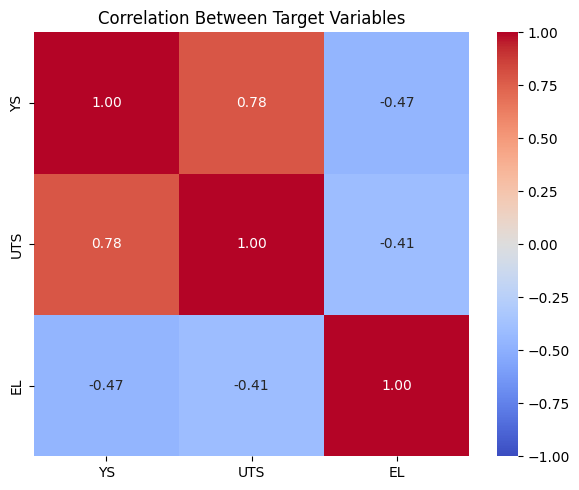

In [23]:
# Correlation among target variables

target_corr = df[["YS", "UTS", "EL"]].corr(method="pearson")

display(target_corr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Target Variables")
plt.tight_layout()
plt.show()

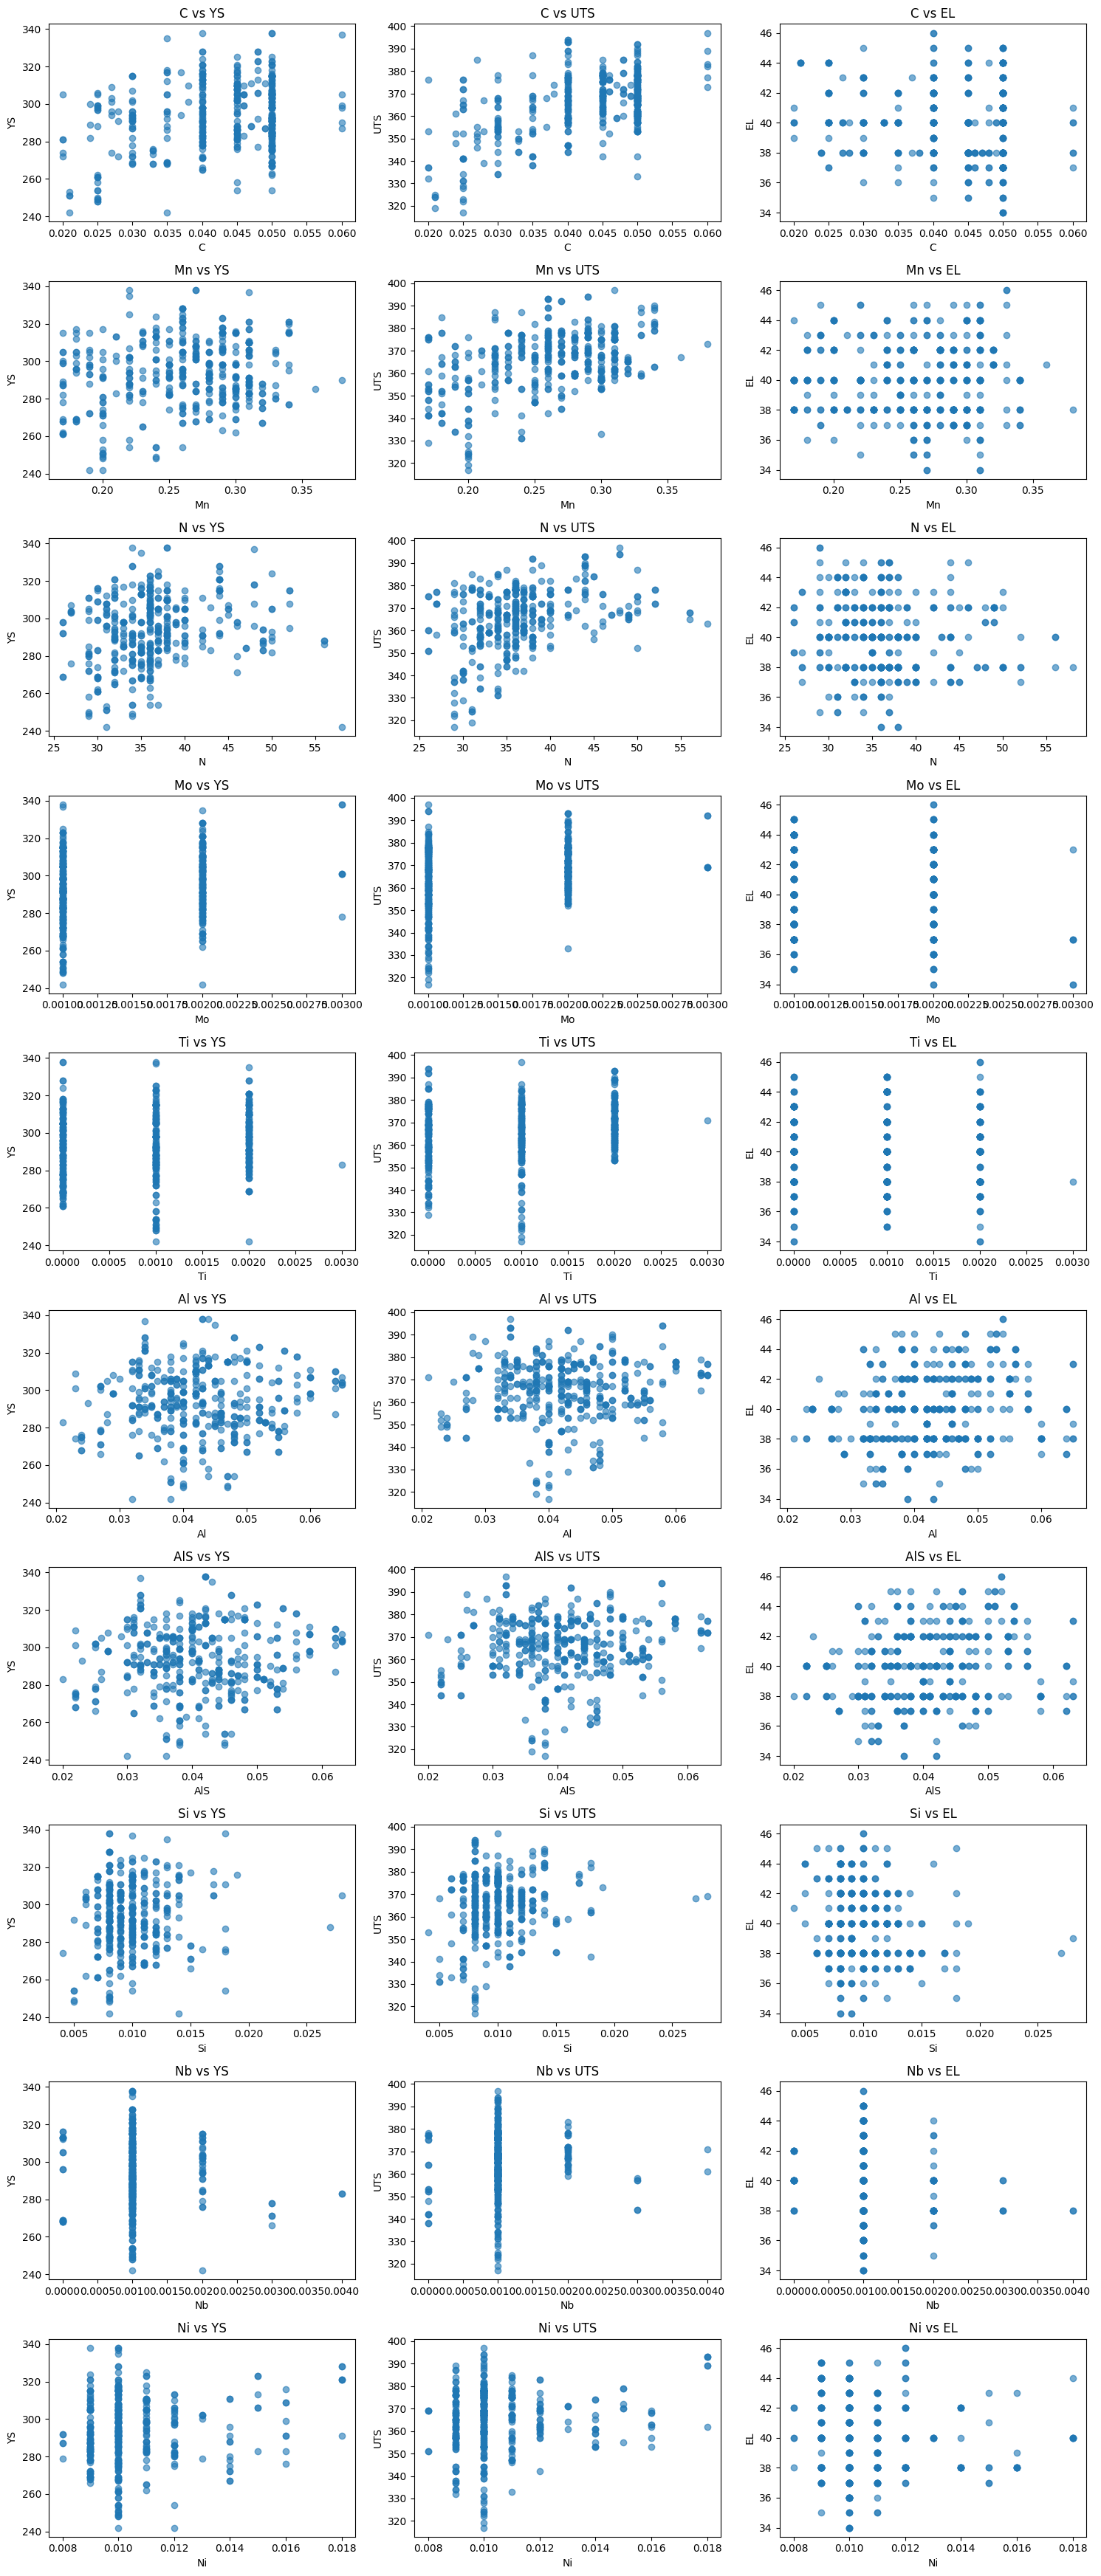

In [24]:
# Feature-target relationships for important features

important_features = [
    "C", "Mn", "N", "Mo", "Ti",
    "Al", "AlS", "Si", "Nb", "Ni"
]

fig, axes = plt.subplots(
    len(important_features),
    3,
    figsize=(15, 35)
)

for i, feature in enumerate(important_features):
    for j, target in enumerate(["YS", "UTS", "EL"]):

        axes[i, j].scatter(
            df[feature],
            df[target],
            alpha=0.6
        )

        axes[i, j].set_xlabel(feature)
        axes[i, j].set_ylabel(target)
        axes[i, j].set_title(f"{feature} vs {target}")

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# ML DATA PREPARATION
# ============================================

feature_cols = [
    "Al", "AlS", "C", "Cr", "Cu", "Mn", "Mo",
    "N", "Nb", "Ni", "P", "S", "Si", "Ti",
    "V", "FRT", "CTT"
]

target_cols = ["YS", "UTS", "EL"]

X = df[feature_cols].copy()
y = df[target_cols].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget variables:")
print(y.columns.tolist())

X shape: (435, 17)
y shape: (435, 3)

Input features:
['Al', 'AlS', 'C', 'Cr', 'Cu', 'Mn', 'Mo', 'N', 'Nb', 'Ni', 'P', 'S', 'Si', 'Ti', 'V', 'FRT', 'CTT']

Target variables:
['YS', 'UTS', 'EL']


In [26]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (348, 17)
y_train: (348, 3)

Testing set:
X_test: (87, 17)
y_test: (87, 3)


In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Create scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

print("Standardized training data shape:", X_train_standard.shape)
print("Standardized test data shape:", X_test_standard.shape)

print("\nMin-Max normalized training data shape:", X_train_minmax.shape)
print("Min-Max normalized test data shape:", X_test_minmax.shape)

Standardized training data shape: (348, 17)
Standardized test data shape: (87, 17)

Min-Max normalized training data shape: (348, 17)
Min-Max normalized test data shape: (87, 17)


In [29]:
# Verify StandardScaler
standard_check = pd.DataFrame(
    X_train_standard,
    columns=feature_cols
)

# Verify MinMaxScaler
minmax_check = pd.DataFrame(
    X_train_minmax,
    columns=feature_cols
)

print("StandardScaler - training data:")
display(standard_check.describe().T[["mean", "std", "min", "max"]])

print("\nMinMaxScaler - training data:")
display(minmax_check.describe().T[["min", "max"]])

StandardScaler - training data:


,mean,std,min,max
Al,4.032534e-16,1.00144,-2.504983,2.504983
AlS,2.807461e-17,1.00144,-2.412676,2.510723
C,5.487309e-16,1.00144,-2.436832,2.014703
Cr,1.100014e-15,1.00144,-2.441926,2.853377
Cu,-1.939700e-16,1.00144,-0.879304,5.495650
Mn,3.675221e-16,1.00144,-1.934427,2.653952
Mo,2.858505e-16,1.00144,-0.862207,2.984564
N,6.227458e-16,1.00144,-1.862873,3.920500
Nb,-5.665966e-16,1.00144,-2.327643,6.429326
Ni,5.997757e-16,1.00144,-1.426331,4.252882



MinMaxScaler - training data:


,min,max
Al,0.0,1.0
AlS,0.0,1.0
C,0.0,1.0
Cr,0.0,1.0
Cu,0.0,1.0
Mn,0.0,1.0
Mo,0.0,1.0
N,0.0,1.0
Nb,0.0,1.0
Ni,0.0,1.0


In [30]:
# ============================================
# ML MODELING SETUP
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import cross_val_score, KFold

import numpy as np

# Cross-validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Modeling framework ready.")
print("Cross-validation: 5-fold")

Modeling framework ready.
Cross-validation: 5-fold


In [31]:
print("CTT distribution in full dataset:")
print(df["CTT"].value_counts().sort_index())

print("\nCTT distribution in training set:")
print(X_train["CTT"].value_counts().sort_index())

print("\nCTT distribution in test set:")
print(X_test["CTT"].value_counts().sort_index())

CTT distribution in full dataset:
CTT
570    432
650      3
Name: count, dtype: int64

CTT distribution in training set:
CTT
570    347
650      1
Name: count, dtype: int64

CTT distribution in test set:
CTT
570    85
650     2
Name: count, dtype: int64


In [32]:
from sklearn.base import clone

models = {
    "Ridge + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Ridge + MinMaxScaler": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "SVR + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(
            SVR(kernel="rbf", C=10, epsilon=0.1)
        ))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
}

results = []

for model_name, model in models.items():
    fold_metrics = {target: {"R2": [], "RMSE": [], "MAE": []}
                    for target in target_cols}

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)

        for j, target in enumerate(target_cols):
            fold_metrics[target]["R2"].append(
                r2_score(y_val[target], pred[:, j])
            )
            fold_metrics[target]["RMSE"].append(
                np.sqrt(mean_squared_error(y_val[target], pred[:, j]))
            )
            fold_metrics[target]["MAE"].append(
                mean_absolute_error(y_val[target], pred[:, j])
            )

    for target in target_cols:
        results.append({
            "Model": model_name,
            "Target": target,
            "R2_mean": np.mean(fold_metrics[target]["R2"]),
            "R2_std": np.std(fold_metrics[target]["R2"]),
            "RMSE_mean": np.mean(fold_metrics[target]["RMSE"]),
            "MAE_mean": np.mean(fold_metrics[target]["MAE"])
        })

baseline_results = pd.DataFrame(results)

print(baseline_results.round(4).to_string(index=False))

                 Model Target  R2_mean  R2_std  RMSE_mean  MAE_mean
Ridge + StandardScaler     YS   0.1164  0.0624    16.6859   13.6694
Ridge + StandardScaler    UTS   0.4460  0.0453    10.3627    8.1882
Ridge + StandardScaler     EL   0.0289  0.0521     2.2815    1.8874
  Ridge + MinMaxScaler     YS   0.1270  0.0486    16.5896   13.6667
  Ridge + MinMaxScaler    UTS   0.4481  0.0357    10.3516    8.2122
  Ridge + MinMaxScaler     EL   0.0384  0.0424     2.2713    1.8826
  SVR + StandardScaler     YS   0.3070  0.0724    14.7485   11.2333
  SVR + StandardScaler    UTS   0.5337  0.0945     9.4312    6.9115
  SVR + StandardScaler     EL   0.2071  0.1054     2.0565    1.4430
         Random Forest     YS   0.4127  0.1355    13.5048    9.7079
         Random Forest    UTS   0.5639  0.0929     9.0965    6.4754
         Random Forest     EL   0.3911  0.0861     1.7987    1.3399
           Extra Trees     YS   0.3279  0.1188    14.5040    9.6694
           Extra Trees    UTS   0.4913  0.0974  

In [33]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Compute MI separately for each target using training data only
mi_tables = {}

for target in target_cols:
    mi = mutual_info_regression(
        X_train,
        y_train[target],
        random_state=42
    )

    mi_df = pd.DataFrame({
        "Feature": feature_cols,
        "MI": mi
    }).sort_values("MI", ascending=False)

    mi_tables[target] = mi_df

    print(f"\n{target} — Mutual Information ranking")
    print(mi_df.round(4).to_string(index=False))


YS — Mutual Information ranking
Feature     MI
     Al 0.4874
      P 0.4624
    AlS 0.4573
     Mn 0.4463
     Cr 0.3953
      N 0.3804
     Si 0.3320
      S 0.2991
      C 0.2840
     Ni 0.1857
     Ti 0.1611
     Nb 0.1251
     Cu 0.1053
     Mo 0.0767
      V 0.0553
    FRT 0.0332
    CTT 0.0000

UTS — Mutual Information ranking
Feature     MI
     Mn 0.4887
      S 0.4723
     Al 0.4642
    AlS 0.4640
      N 0.4405
     Cr 0.4172
      P 0.3859
      C 0.3208
     Si 0.2631
     Ni 0.2101
     Cu 0.1854
     Ti 0.1479
     Mo 0.1114
     Nb 0.1079
      V 0.0672
    FRT 0.0369
    CTT 0.0365

EL — Mutual Information ranking
Feature     MI
     Al 0.2734
    AlS 0.2617
     Cr 0.2243
      P 0.2207
      N 0.1995
     Mn 0.1728
      C 0.1604
     Ti 0.0768
     Ni 0.0745
      S 0.0702
     Si 0.0682
    CTT 0.0558
    FRT 0.0335
      V 0.0276
     Cu 0.0114
     Nb 0.0018
     Mo 0.0000


In [34]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.pipeline import Pipeline

mi_rf_results = []

for target in target_cols:
    print(f"\n===== {target} =====")

    y_target = y_train[target]

    for k in [5, 8, 12, 17]:
        fold_r2, fold_rmse, fold_mae = [], [], []

        for train_idx, val_idx in cv.split(X_train):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_target.iloc[train_idx]
            y_val = y_target.iloc[val_idx]

            selector = SelectKBest(
                score_func=mutual_info_regression,
                k=k
            )

            X_tr_sel = selector.fit_transform(X_tr, y_tr)
            X_val_sel = selector.transform(X_val)

            model = RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr_sel, y_tr)
            pred = model.predict(X_val_sel)

            fold_r2.append(r2_score(y_val, pred))
            fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
            fold_mae.append(mean_absolute_error(y_val, pred))

        mi_rf_results.append({
            "Target": target,
            "Top_k": k,
            "R2_mean": np.mean(fold_r2),
            "R2_std": np.std(fold_r2),
            "RMSE_mean": np.mean(fold_rmse),
            "MAE_mean": np.mean(fold_mae)
        })

mi_rf_results = pd.DataFrame(mi_rf_results)

print("\nMI-selected Random Forest results:")
print(mi_rf_results.round(4).to_string(index=False))


===== YS =====

===== UTS =====

===== EL =====

MI-selected Random Forest results:
Target  Top_k  R2_mean  R2_std  RMSE_mean  MAE_mean
    YS      5   0.4304  0.1434    13.2874    9.5923
    YS      8   0.4672  0.1438    12.8497    9.2754
    YS     12   0.4688  0.1387    12.8460    9.2383
    YS     17   0.4118  0.1256    13.5370    9.7581
   UTS      5   0.5778  0.1190     8.8950    6.3705
   UTS      8   0.5780  0.0964     8.9304    6.2871
   UTS     12   0.5907  0.0859     8.8112    6.1877
   UTS     17   0.5565  0.0893     9.1850    6.5398
    EL      5   0.3523  0.1103     1.8489    1.3196
    EL      8   0.3716  0.1045     1.8216    1.3099
    EL     12   0.3543  0.0890     1.8504    1.3541
    EL     17   0.3455  0.0649     1.8685    1.3935


In [35]:
import importlib.util

print("XGBoost:", "Available" if importlib.util.find_spec("xgboost") else "Not installed")
print("LightGBM:", "Available" if importlib.util.find_spec("lightgbm") else "Not installed")

XGBoost: Available
LightGBM: Available


In [36]:
from xgboost import XGBRegressor

xgb_results = []

for target in target_cols:
    print(f"\n===== {target} =====")

    y_target = y_train[target]

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_target.iloc[train_idx]
        y_val = y_target.iloc[val_idx]

        # MI feature selection inside each fold
        selector = SelectKBest(
            score_func=mutual_info_regression,
            k=12
        )

        X_tr_sel = selector.fit_transform(X_tr, y_tr)
        X_val_sel = selector.transform(X_val)

        model = XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr_sel, y_tr)
        pred = model.predict(X_val_sel)

        xgb_results.append({
            "Target": target,
            "R2": r2_score(y_val, pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
            "MAE": mean_absolute_error(y_val, pred)
        })

xgb_results = pd.DataFrame(xgb_results)

summary_xgb = xgb_results.groupby("Target").agg(
    R2_mean=("R2", "mean"),
    R2_std=("R2", "std"),
    RMSE_mean=("RMSE", "mean"),
    MAE_mean=("MAE", "mean")
).reset_index()

print("\nXGBoost 5-fold CV:")
print(summary_xgb.round(4).to_string(index=False))


===== YS =====

===== UTS =====

===== EL =====

XGBoost 5-fold CV:
Target  R2_mean  R2_std  RMSE_mean  MAE_mean
    EL   0.3067  0.1178     1.9162    1.4040
   UTS   0.5602  0.1111     9.1286    6.3244
    YS   0.4572  0.1533    13.0190    9.2423


In [37]:
from lightgbm import LGBMRegressor

lgb_results = []

for target in target_cols:
    print(f"\n===== {target} =====")

    y_target = y_train[target]

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_target.iloc[train_idx]
        y_val = y_target.iloc[val_idx]

        # Feature selection inside each fold
        selector = SelectKBest(
            score_func=mutual_info_regression,
            k=12
        )

        X_tr_sel = selector.fit_transform(X_tr, y_tr)
        X_val_sel = selector.transform(X_val)

        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            num_leaves=15,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=1.0,
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        )

        model.fit(X_tr_sel, y_tr)
        pred = model.predict(X_val_sel)

        lgb_results.append({
            "Target": target,
            "R2": r2_score(y_val, pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
            "MAE": mean_absolute_error(y_val, pred)
        })

lgb_results = pd.DataFrame(lgb_results)

summary_lgb = lgb_results.groupby("Target").agg(
    R2_mean=("R2", "mean"),
    R2_std=("R2", "std"),
    RMSE_mean=("RMSE", "mean"),
    MAE_mean=("MAE", "mean")
).reset_index()

print("\nLightGBM 5-fold CV:")
print(summary_lgb.round(4).to_string(index=False))


===== YS =====


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



===== UTS =====


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



===== EL =====


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM 5-fold CV:
Target  R2_mean  R2_std  RMSE_mean  MAE_mean
    EL   0.3370  0.1326     1.8709    1.4465
   UTS   0.5671  0.0971     9.0758    6.4524
    YS   0.4297  0.1602    13.3383    9.7440


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [38]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

final_models = {
    "YS": {
        "k": 12,
        "model": RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    },
    "UTS": {
        "k": 12,
        "model": RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    },
    "EL": {
        "k": 8,
        "model": RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    }
}

final_results = []

for target in target_cols:
    k = final_models[target]["k"]
    model = final_models[target]["model"]

    selector = SelectKBest(
        score_func=mutual_info_regression,
        k=k
    )

    X_tr_sel = selector.fit_transform(X_train, y_train[target])
    X_te_sel = selector.transform(X_test)

    model.fit(X_tr_sel, y_train[target])
    pred = model.predict(X_te_sel)

    final_results.append({
        "Target": target,
        "R2_test": r2_score(y_test[target], pred),
        "RMSE_test": np.sqrt(mean_squared_error(y_test[target], pred)),
        "MAE_test": mean_absolute_error(y_test[target], pred)
    })

final_results = pd.DataFrame(final_results)

print("FINAL HELD-OUT TEST RESULTS")
print(final_results.round(4).to_string(index=False))

FINAL HELD-OUT TEST RESULTS
Target  R2_test  RMSE_test  MAE_test
    YS   0.1414    15.1398   10.5135
   UTS   0.2337     9.4020    6.4441
    EL   0.5491     1.6861    1.0916


In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack_results = []

for target in target_cols:
    print(f"\n===== {target} =====")

    stack_model = StackingRegressor(
        estimators=[
            ("rf", RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                random_state=42,
                n_jobs=-1
            )),
            ("et", ExtraTreesRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )),
            ("gb", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )),
            ("svr", Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVR(C=10, epsilon=0.1, kernel="rbf"))
            ]))
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=5,
        n_jobs=-1
    )

    fold_r2, fold_rmse, fold_mae = [], [], []

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train[target].iloc[train_idx]
        y_val = y_train[target].iloc[val_idx]

        stack_model.fit(X_tr, y_tr)
        pred = stack_model.predict(X_val)

        fold_r2.append(r2_score(y_val, pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
        fold_mae.append(mean_absolute_error(y_val, pred))

    stack_results.append({
        "Target": target,
        "R2_mean": np.mean(fold_r2),
        "R2_std": np.std(fold_r2),
        "RMSE_mean": np.mean(fold_rmse),
        "MAE_mean": np.mean(fold_mae)
    })

stack_results = pd.DataFrame(stack_results)

print("\nSTACKING 5-FOLD CV")
print(stack_results.round(4).to_string(index=False))


===== YS =====

===== UTS =====

===== EL =====

STACKING 5-FOLD CV
Target  R2_mean  R2_std  RMSE_mean  MAE_mean
    YS   0.3995  0.0980    13.7397   10.1448
   UTS   0.5577  0.0730     9.2055    6.6772
    EL   0.3383  0.0774     1.8772    1.3937


In [40]:
comparison = pd.DataFrame({
    "Target": target_cols,
    "Train_mean": [y_train[c].mean() for c in target_cols],
    "Test_mean": [y_test[c].mean() for c in target_cols],
    "Train_std": [y_train[c].std() for c in target_cols],
    "Test_std": [y_test[c].std() for c in target_cols],
    "Train_min": [y_train[c].min() for c in target_cols],
    "Test_min": [y_test[c].min() for c in target_cols],
    "Train_max": [y_train[c].max() for c in target_cols],
    "Test_max": [y_test[c].max() for c in target_cols],
})

print(comparison.round(3).to_string(index=False))

Target  Train_mean  Test_mean  Train_std  Test_std  Train_min  Test_min  Train_max  Test_max
    YS     293.000    296.701     17.960    16.434        242       262        338       338
   UTS     364.822    367.632     14.074    10.803        317       333        394       397
    EL      40.009     39.621      2.343     2.525         34        34         46        45


In [41]:
from sklearn.model_selection import RepeatedKFold

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

repeated_results = []

for target in target_cols:
    y_target = y_train[target]

    fold_r2 = []
    fold_rmse = []
    fold_mae = []

    for train_idx, val_idx in repeated_cv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_target.iloc[train_idx]
        y_val = y_target.iloc[val_idx]

        k = {"YS": 12, "UTS": 12, "EL": 8}[target]

        selector = SelectKBest(
            score_func=mutual_info_regression,
            k=k
        )

        X_tr_sel = selector.fit_transform(X_tr, y_tr)
        X_val_sel = selector.transform(X_val)

        model = RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr_sel, y_tr)
        pred = model.predict(X_val_sel)

        fold_r2.append(r2_score(y_val, pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
        fold_mae.append(mean_absolute_error(y_val, pred))

    repeated_results.append({
        "Target": target,
        "R2_mean": np.mean(fold_r2),
        "R2_std": np.std(fold_r2),
        "R2_min": np.min(fold_r2),
        "R2_max": np.max(fold_r2),
        "RMSE_mean": np.mean(fold_rmse),
        "MAE_mean": np.mean(fold_mae)
    })

repeated_results = pd.DataFrame(repeated_results)

print("25-FOLD REPEATED CROSS-VALIDATION")
print(repeated_results.round(4).to_string(index=False))

25-FOLD REPEATED CROSS-VALIDATION
Target  R2_mean  R2_std  R2_min  R2_max  RMSE_mean  MAE_mean
    YS   0.4369  0.1403  0.0845  0.6533    13.1519    9.3954
   UTS   0.5663  0.1377  0.0735  0.7438     8.9970    6.3371
    EL   0.3903  0.1105  0.1021  0.5714     1.8038    1.3123


In [42]:
# Final models based on repeated-CV results
final_rf_models = {}
final_predictions = {}
final_selectors = {}

best_k = {
    "YS": 12,
    "UTS": 12,
    "EL": 8
}

for target in target_cols:

    selector = SelectKBest(
        score_func=mutual_info_regression,
        k=best_k[target]
    )

    X_train_sel = selector.fit_transform(
        X_train, y_train[target]
    )
    X_test_sel = selector.transform(X_test)

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_sel, y_train[target])

    pred = model.predict(X_test_sel)

    final_selectors[target] = selector
    final_rf_models[target] = model
    final_predictions[target] = pred

    selected_features = np.array(feature_cols)[
        selector.get_support()
    ]

    print(f"\n{target}")
    print("Selected features:")
    print(", ".join(selected_features))


YS
Selected features:
Al, AlS, C, Cr, Mn, N, Nb, Ni, P, S, Si, Ti

UTS
Selected features:
Al, AlS, C, Cr, Mn, N, Nb, Ni, P, S, Si, Ti

EL
Selected features:
Al, AlS, C, Cr, Mn, N, Ni, P



YS — SHAP importance


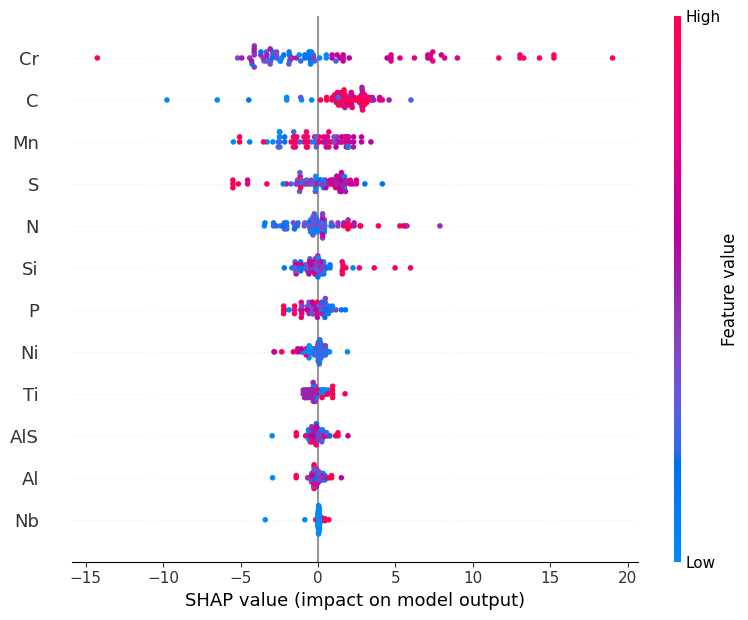


UTS — SHAP importance


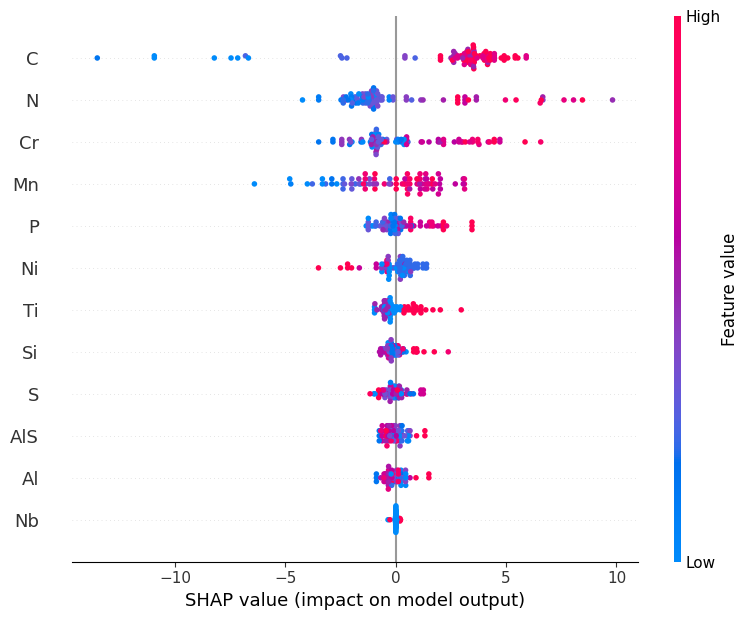


EL — SHAP importance


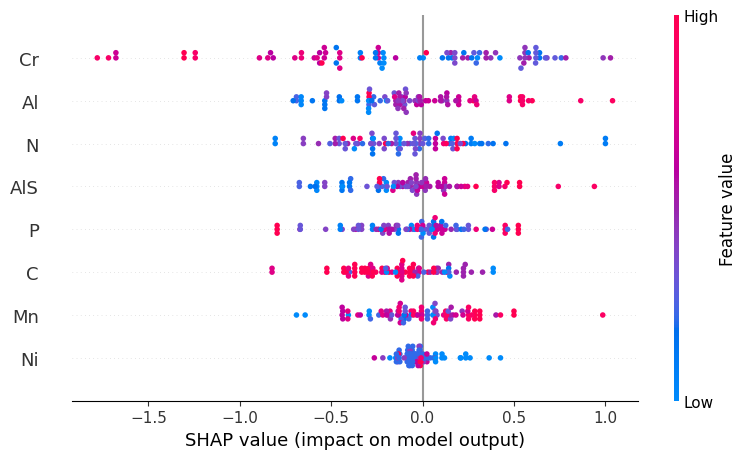

In [43]:
import shap
import matplotlib.pyplot as plt

shap_values_all = {}

for target in target_cols:

    model = final_rf_models[target]
    selector = final_selectors[target]

    X_test_selected = selector.transform(X_test)

    # Recover selected feature names
    selected_features = np.array(feature_cols)[selector.get_support()]

    # SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_selected)

    shap_values_all[target] = {
        "values": shap_values,
        "features": selected_features,
        "X": X_test_selected
    }

    print(f"\n{target} — SHAP importance")

    shap.summary_plot(
        shap_values,
        X_test_selected,
        feature_names=selected_features,
        show=True
    )

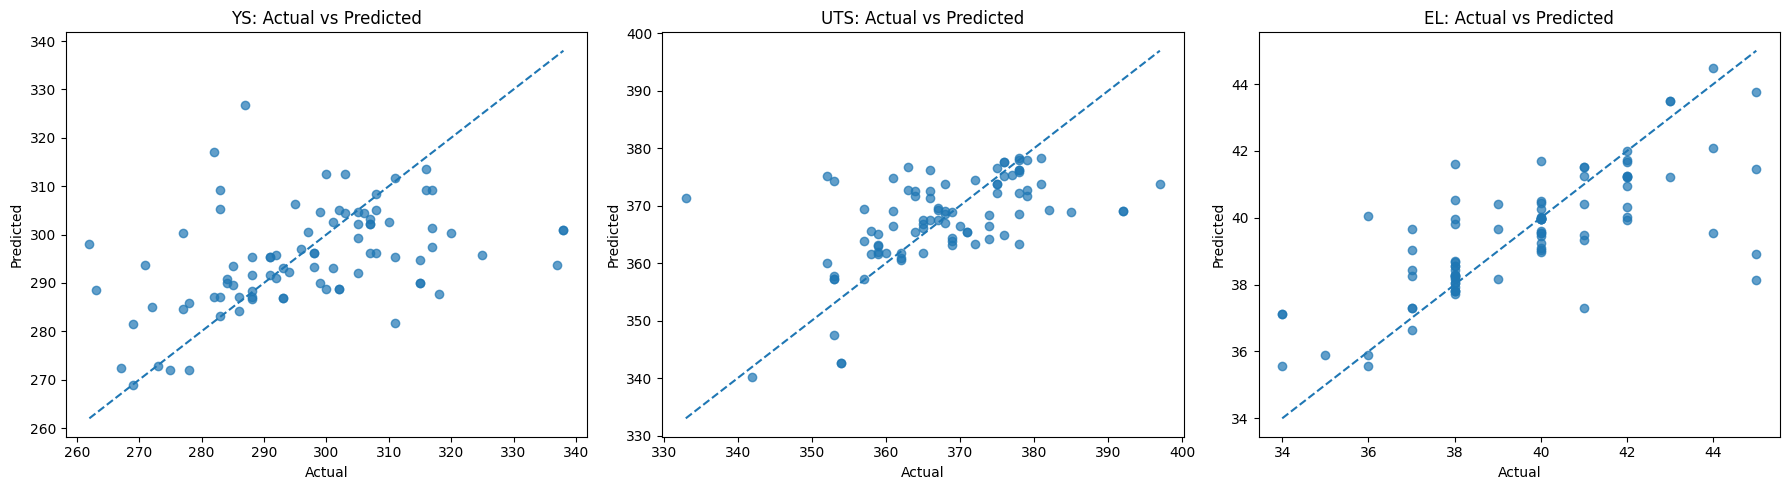

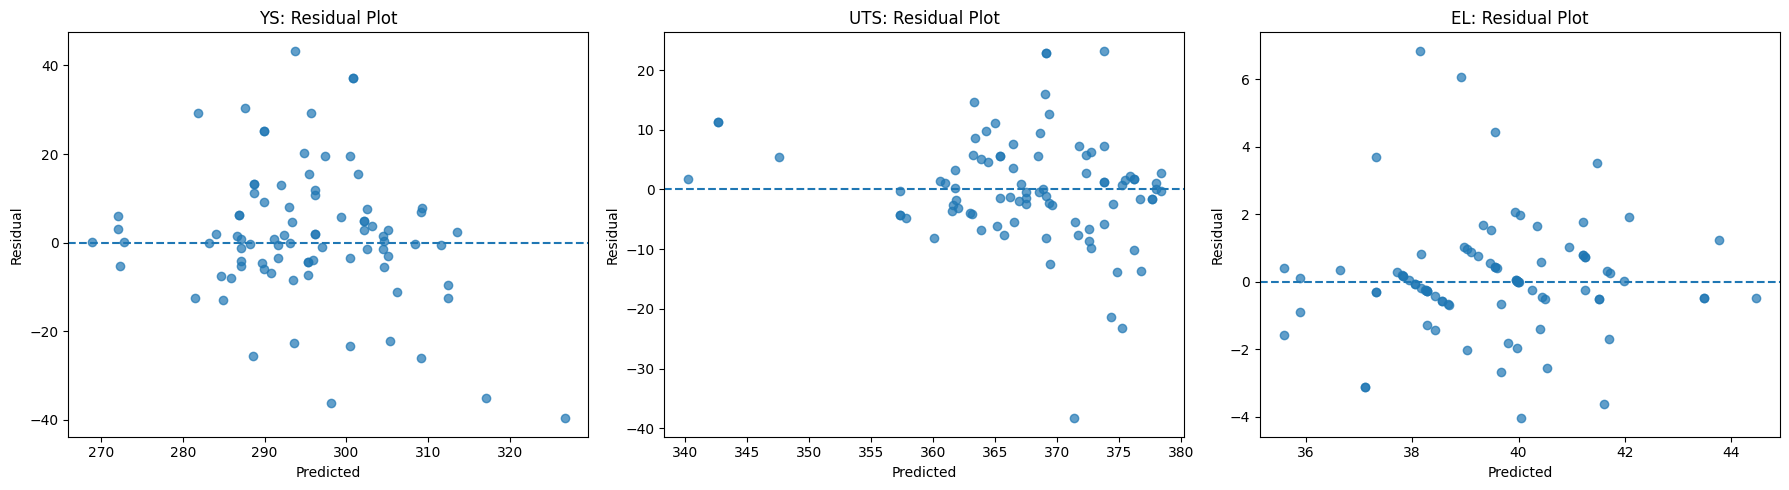

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(target_cols):
    actual = y_test[target].values
    predicted = final_predictions[target]

    axes[i].scatter(actual, predicted, alpha=0.7)

    # Ideal prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())

    axes[i].plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")
    axes[i].set_title(f"{target}: Actual vs Predicted")

plt.tight_layout()
plt.show()


# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(target_cols):
    actual = y_test[target].values
    predicted = final_predictions[target]
    residuals = actual - predicted

    axes[i].scatter(predicted, residuals, alpha=0.7)
    axes[i].axhline(0, linestyle="--")

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residual")
    axes[i].set_title(f"{target}: Residual Plot")

plt.tight_layout()
plt.show()

In [45]:
# Final model comparison

comparison = pd.DataFrame({
    "Target": target_cols,
    "Repeated_CV_R2": [0.4369, 0.5663, 0.3903],
    "Repeated_CV_RMSE": [13.1519, 8.9970, 1.8038],
    "Repeated_CV_MAE": [9.3954, 6.3371, 1.3123],
    "Test_R2": [0.1414, 0.2337, 0.5491],
    "Test_RMSE": [15.1398, 9.4020, 1.6861],
    "Test_MAE": [10.5135, 6.4441, 1.0916]
})

print("FINAL MODEL PERFORMANCE")
print(comparison.round(4).to_string(index=False))

print("\nSelected features:")
for target in target_cols:
    features = np.array(feature_cols)[
        final_selectors[target].get_support()
    ]
    print(f"{target}: {', '.join(features)}")

FINAL MODEL PERFORMANCE
Target  Repeated_CV_R2  Repeated_CV_RMSE  Repeated_CV_MAE  Test_R2  Test_RMSE  Test_MAE
    YS          0.4369           13.1519           9.3954   0.1414    15.1398   10.5135
   UTS          0.5663            8.9970           6.3371   0.2337     9.4020    6.4441
    EL          0.3903            1.8038           1.3123   0.5491     1.6861    1.0916

Selected features:
YS: Al, AlS, C, Cr, Mn, N, Nb, Ni, P, S, Si, Ti
UTS: Al, AlS, C, Cr, Mn, N, Nb, Ni, P, S, Si, Ti
EL: Al, AlS, C, Cr, Mn, N, Ni, P
